In [3]:
from model_v1_w5ms3.DataLoader import TempFlowDataset_disp
from model_v1_w5ms3.neuralop_seg.uno import UNO

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

Data prep

In [50]:

dataset = TempFlowDataset_disp(
    root = '../Data',
    split = 'training',
    image_folder = 'image_2',
    flow_type = 'flow_occ',
    disp_type= 'disp_occ',
    seq_len = 4, # 3 flows
    center_frame_idx = 10,
    crop_size = (352, 1216),
    normalize = True,
    stats_in = 'stats.json',
    return_pair_only = False,
)


# lighter-weight single-flow version

"""
dataset = TempFlowDataset_disp(
    root = '../Data',
    split = 'training',
    image_folder = 'image_2',
    flow_type = 'flow_occ',
    disp_type= 'disp_occ',
    seq_len = 2, # 1 flow
    center_frame_idx = 10,
    crop_size = (352, 1216),
    normalize = True,
    stats_in = 'stats.json',
    return_pair_only = True,
)
"""



train_loader = DataLoader(dataset, batch_size=2, shuffle=True)

In [51]:
batch = next(iter(train_loader))
print(batch['imgs'].shape)

torch.Size([2, 4, 3, 352, 1216])


Encoders

In [52]:
import importlib
import model_v1_w5ms3.Encoders as Encoders
importlib.reload(Encoders)
from model_v1_w5ms3.Encoders import (SequencePairEncoder, VisualBranchCNN, 
                                     MotionBranchCNN, SpatialTemporalFusion_timeAware)

import model_v1_w5ms3.Decoders as Decoders
importlib.reload(Decoders)
from model_v1_w5ms3.Decoders import FlowDecoder

In [53]:
# -------------------------
# 1. Pairwise motion encoder
# -------------------------
pair_encoder = SequencePairEncoder(
    feat_ch=64,         # backbone feature channels
    corr_radius=4,      # local cost-volume radius
    embed_ch=128,       # output pair embedding channels
    predict_flow=True   # also return coarse pairwise flow_init
)

# -------------------------
# 2. Raw visual branch
# -------------------------
visual_branch = VisualBranchCNN(
    in_ch=3,
    base_ch=32,
    out_ch=64
)

# -------------------------
# 3. Motion branch
# -------------------------
# input should match pair_encoder embed_ch
motion_branch = MotionBranchCNN(
    in_ch=128,
    hidden_ch=128,
    out_ch=64
)

# -------------------------
# 4. Motion-Vision-Light Temporal fusion
# -------------------------
# should return [B, Tm, hidden_ch, H, W]
fusion = SpatialTemporalFusion_timeAware(
    visual_ch=64,
    motion_ch=64,
    hidden_ch=128,
    out_ch=128
)

# -------------------------
# 5. UNO
# -------------------------
uno = UNO(
    in_channels=128,
    out_channels=128,
    hidden_channels=64,
    lifting_channels=64,
    projection_channels=128,
    positional_embedding=None,
    n_layers=4,
    uno_out_channels=[64, 96, 96, 64],
    uno_n_modes=[[12, 16], [10, 12], [10, 12], [12, 16]],
    uno_scalings=[[1.0, 1.0], [0.5, 0.5], [2.0, 2.0], [1.0, 1.0]],
    fno_skip="linear",
    horizontal_skip="linear",
    channel_mlp_skip="linear",
)

# -------------------------
# 6. Decoder
# -------------------------
decoder = FlowDecoder(
    in_ch=128,            # must match fusion output channels; hard code #prev_flows=2
    hidden_ch=64,
    upsample=8,    # use 4 if fusion output is H/4, use 8 if H/8. Match upsample x.
    use_prev_flow=True
)

Train

In [54]:
def epe_loss(pred, gt, valid=None):
    """
    pred:  [B, 2, H, W]
    gt:    [B, 2, H, W]
    valid: [B, H, W] or [B, 1, H, W] or None
    """
    epe = torch.norm(pred - gt, dim=1)  # [B, H, W]

    if valid is not None:
        if valid.ndim == 4:
            valid = valid[:, 0]
        valid = valid.float()
        return (epe * valid).sum() / (valid.sum() + 1e-6)

    return epe.mean()


def temporal_loss(flows):
    """
    flows: [B, Tm, 2, H, W]
    """
    if flows.shape[1] < 2:
        return flows.new_tensor(0.0)
    return (flows[:, 1:] - flows[:, :-1]).abs().mean()


def smoothness_loss(flow):
    """
    flow: [B, 2, H, W]
    """
    dx = flow[:, :, :, 1:] - flow[:, :, :, :-1]
    dy = flow[:, :, 1:, :] - flow[:, :, :-1, :]
    return dx.abs().mean() + dy.abs().mean()


def select_gt_flow(pred_flows, src_idx):
    """
    pred_flows: [B, Tm, 2, H, W]
    src_idx:    [B]
    Returns:
        [B, 2, H, W]
    """
    B = pred_flows.shape[0]
    out = []
    for b in range(B):
        t = int(src_idx[b].item())
        out.append(pred_flows[b, t])
    return torch.stack(out, dim=0)

def forward_pipeline(imgs, pair_encoder, visual_branch, motion_branch, fusion, uno, decoder):
    """
    imgs: [B, T, 3, H, W]

    Returns dict with:
      flows:      [B, Tm, 2, H, W]
      flow_inits: [B, Tm, 2, h, w] or None
      pair_feats: [B, Tm, Cp, h, w]
      corrs:      [B, Tm, K, h, w]
      fused_seq:  [B, Tm, Cf, h, w]
    """
    pair_out = pair_encoder(imgs)
    pair_feats = pair_out["pair_feats"]      # [B, Tm, 128, h, w]
    flow_inits = pair_out["flow_inits"]      # [B, Tm, 2, h, w] or None
    corrs = pair_out["corrs"]

    visual_feats = visual_branch(imgs)       # [B, T, 64, h, w]
    motion_feats = motion_branch(pair_feats) # [B, Tm, 64, h, w]
    
    fused_seq = fusion(visual_feats, motion_feats)  # [B, Tm, 128, h, w]
    # plug UNO block here
    # -----------
    B, Tm, C, H, W = fused_seq.shape
    x = fused_seq.reshape(B * Tm, C, H, W)
    uno_out = uno(x)
    x = uno_out.reshape(B, Tm, C, H, W)
    flows = decoder(x)                      # [B, Tm, 2, H, W]

    return {
        "flows": flows,
        "flow_inits": flow_inits,
        "pair_feats": pair_feats,
        "corrs": corrs,
        "fused_seq": fused_seq,
        "uno": uno_out
    }

class Trainer:
    def __init__(
        self,
        pair_encoder,
        visual_branch,
        motion_branch,
        fusion,
        uno,
        decoder,
        optimizer,
        device,
        lambda_temp=0.1,
        lambda_smooth=0.01,
    ):
        self.pair_encoder = pair_encoder
        self.visual_branch = visual_branch
        self.motion_branch = motion_branch
        self.fusion = fusion
        self.uno = uno
        self.decoder = decoder
        self.optimizer = optimizer
        self.device = device

        self.lambda_temp = lambda_temp
        self.lambda_smooth = lambda_smooth

    def train_mode(self):
        self.pair_encoder.train()
        self.visual_branch.train()
        self.motion_branch.train()
        self.fusion.train()
        self.uno.train()
        self.decoder.train()

    def eval_mode(self):
        self.pair_encoder.eval()
        self.visual_branch.eval()
        self.motion_branch.eval()
        self.fusion.eval() 
        self.uno.eval()
        self.decoder.eval()

    def train_step(self, batch):
        self.train_mode()

        imgs = batch["imgs"].to(self.device)                  # [B, T, 3, H, W]
        gt_flow = batch["flow"].to(self.device)               # [B, 2, H, W]
        valid = batch["valid"].to(self.device)                # [B, H, W] or [B,1,H,W]
        src_idx = batch["src_idx_in_seq"].to(self.device)     # [B]

        out = forward_pipeline(
            imgs,
            self.pair_encoder,
            self.visual_branch,
            self.motion_branch,
            self.fusion,
            self.uno,
            self.decoder,
        )

        pred_flows = out["flows"]                             # [B, Tm, 2, H, W]
        pred = select_gt_flow(pred_flows, src_idx)           # [B, 2, H, W]

        loss_flow = epe_loss(pred, gt_flow, valid)
        loss_temp = temporal_loss(pred_flows)
        loss_smooth = smoothness_loss(pred)

        loss = (
            loss_flow
            + self.lambda_temp * loss_temp
            + self.lambda_smooth * loss_smooth
        )

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return {
            "loss": float(loss.item()),
            "loss_flow": float(loss_flow.item()),
            "loss_temp": float(loss_temp.item()),
            "loss_smooth": float(loss_smooth.item()),
        }

    @torch.no_grad()
    def val_step(self, batch):
        self.eval_mode()

        imgs = batch["imgs"].to(self.device)
        gt_flow = batch["flow"].to(self.device)
        valid = batch["valid"].to(self.device)
        src_idx = batch["src_idx_in_seq"].to(self.device)

        out = forward_pipeline(
            imgs,
            self.pair_encoder,
            self.visual_branch,
            self.motion_branch,
            self.fusion,
            self.uno,
            self.decoder,
        )

        pred_flows = out["flows"]
        pred = select_gt_flow(pred_flows, src_idx)

        loss_flow = epe_loss(pred, gt_flow, valid)
        loss_temp = temporal_loss(pred_flows)
        loss_smooth = smoothness_loss(pred)

        loss = (
            loss_flow
            + self.lambda_temp * loss_temp
            + self.lambda_smooth * loss_smooth
        )

        return {
            "loss": float(loss.item()),
            "loss_flow": float(loss_flow.item()),
            "loss_temp": float(loss_temp.item()),
            "loss_smooth": float(loss_smooth.item()),
        }

In [55]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

pair_encoder = pair_encoder.to(device)
visual_branch = visual_branch.to(device)
motion_branch = motion_branch.to(device)
fusion = fusion.to(device)
uno = uno.to(device)
decoder = decoder.to(device)

optimizer = torch.optim.AdamW(
    list(pair_encoder.parameters()) +
    list(visual_branch.parameters()) +
    list(motion_branch.parameters()) +
    list(fusion.parameters()) +
    list(uno.parameters()) + 
    list(decoder.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

trainer = Trainer(
    pair_encoder=pair_encoder,
    visual_branch=visual_branch,
    motion_branch=motion_branch,
    fusion=fusion,
    uno=uno,
    decoder=decoder,
    optimizer=optimizer,
    device=device,
)

In [56]:
batch = next(iter(train_loader))
imgs = batch["imgs"].to(device)

pair_encoder.eval()
visual_branch.eval()
motion_branch.eval()
fusion.eval()
uno.eval()
decoder.eval()

with torch.no_grad():
    out = forward_pipeline(
        imgs,
        pair_encoder,
        visual_branch,
        motion_branch,
        fusion,
        uno,
        decoder,
    )

print("imgs:", imgs.shape)
print("pred flows:", out["flows"].shape)
print("pair_feats:", out["pair_feats"].shape)
print("fused_seq:", out["fused_seq"].shape)
print("uno_out:", out['uno'].shape)

if out["flow_inits"] is not None:
    print("flow_inits:", out["flow_inits"].shape)

print("gt flow:", batch["flow"].shape)
print("valid:", batch["valid"].shape)
print("src_idx_in_seq:", batch["src_idx_in_seq"])

imgs: torch.Size([2, 4, 3, 352, 1216])
pred flows: torch.Size([2, 3, 2, 352, 1216])
pair_feats: torch.Size([2, 3, 128, 44, 152])
fused_seq: torch.Size([2, 3, 128, 44, 152])
uno_out: torch.Size([6, 128, 44, 152])
flow_inits: torch.Size([2, 3, 2, 44, 152])
gt flow: torch.Size([2, 2, 352, 1216])
valid: torch.Size([2, 352, 1216])
src_idx_in_seq: tensor([2, 2])


In [57]:
num_epochs = 10

for epoch in range(num_epochs):
    running = {"loss": 0.0, "loss_flow": 0.0, "loss_temp": 0.0, "loss_smooth": 0.0}
    n_batches = 0

    for batch in train_loader:
        stats = trainer.train_step(batch)
        for k in running:
            running[k] += stats[k]
        n_batches += 1

    avg = {k: v / max(n_batches, 1) for k, v in running.items()}

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"loss={avg['loss']:.4f} | "
        f"flow={avg['loss_flow']:.4f} | "
        f"temp={avg['loss_temp']:.4f} | "
        f"smooth={avg['loss_smooth']:.4f}"
    )

Epoch 1/10 | loss=32.2319 | flow=32.1735 | temp=0.5771 | smooth=0.0697
Epoch 2/10 | loss=28.2655 | flow=28.1759 | temp=0.8851 | smooth=0.1049
Epoch 3/10 | loss=25.8877 | flow=25.7656 | temp=1.2070 | smooth=0.1429
Epoch 4/10 | loss=22.6904 | flow=22.5568 | temp=1.3190 | smooth=0.1656
Epoch 5/10 | loss=21.6329 | flow=21.4912 | temp=1.3983 | smooth=0.1871
Epoch 6/10 | loss=21.5575 | flow=21.3884 | temp=1.6699 | smooth=0.2117
Epoch 7/10 | loss=19.9537 | flow=19.7764 | temp=1.7507 | smooth=0.2226
Epoch 8/10 | loss=18.9563 | flow=18.7522 | temp=2.0174 | smooth=0.2407
Epoch 9/10 | loss=18.1479 | flow=17.9241 | temp=2.2118 | smooth=0.2581
Epoch 10/10 | loss=17.0748 | flow=16.8616 | temp=2.1044 | smooth=0.2713


Visualization

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import torch


def flow_to_rgb(flow):
    """
    flow: torch.Tensor or np.ndarray of shape [2, H, W]
    returns: np.ndarray [H, W, 3] in [0,1]
    """
    if isinstance(flow, torch.Tensor):
        flow = flow.detach().cpu().numpy()

    u = flow[0]
    v = flow[1]

    mag = np.sqrt(u**2 + v**2)
    ang = np.arctan2(v, u)  # [-pi, pi]

    hue = (ang + np.pi) / (2 * np.pi)   # [0,1]
    sat = np.ones_like(hue)
    val = mag / (np.max(mag) + 1e-6)
    val = np.clip(val, 0, 1)

    hsv = np.stack([hue, sat, val], axis=-1)

    import matplotlib.colors as mcolors
    rgb = mcolors.hsv_to_rgb(hsv)
    return rgb


def tensor_img_to_np(img):
    """
    img: [3, H, W], normalized or unnormalized
    returns: [H, W, 3]
    """
    if isinstance(img, torch.Tensor):
        img = img.detach().cpu()

    img = img.permute(1, 2, 0).numpy()

    # simple min-max for display
    img_min, img_max = img.min(), img.max()
    if img_max > img_min:
        img = (img - img_min) / (img_max - img_min)
    else:
        img = np.zeros_like(img)

    return img


def compute_epe_map(pred, gt, valid=None):
    """
    pred, gt: [2, H, W]
    valid: [H, W] or None
    """
    if isinstance(pred, torch.Tensor):
        pred = pred.detach().cpu()
    if isinstance(gt, torch.Tensor):
        gt = gt.detach().cpu()

    epe = torch.norm(pred - gt, dim=0)

    if valid is not None:
        if isinstance(valid, np.ndarray):
            valid = torch.from_numpy(valid)
        valid = valid.detach().cpu().float()
        epe = epe * valid

    return epe.numpy()

def select_gt_flow_single(pred_flows, src_idx, b=0):
    """
    pred_flows: [B, Tm, 2, H, W]
    src_idx: [B]
    b: sample index in batch
    """
    t = int(src_idx[b].item())
    return pred_flows[b, t]

In [44]:
def visualize_batch_result(batch, pred_flows, sample_idx=0):
    """
    batch: dataloader batch
    pred_flows: [B, Tm, 2, H, W]
    """
    img_src = batch["img_src"][sample_idx]
    img_tgt = batch["img_tgt"][sample_idx]
    gt_flow = batch["flow"][sample_idx]
    valid = batch["valid"][sample_idx]
    src_idx = batch["src_idx_in_seq"]

    pred = select_gt_flow_single(pred_flows, src_idx, b=sample_idx)

    img_src_np = tensor_img_to_np(img_src)
    img_tgt_np = tensor_img_to_np(img_tgt)
    pred_rgb = flow_to_rgb(pred)
    gt_rgb = flow_to_rgb(gt_flow)
    epe_map = compute_epe_map(pred, gt_flow, valid)

    fig, axes = plt.subplots(1, 5, figsize=(22, 5))

    axes[0].imshow(img_src_np)
    axes[0].set_title("Source Image")
    axes[0].axis("off")

    axes[1].imshow(img_tgt_np)
    axes[1].set_title("Target Image")
    axes[1].axis("off")

    axes[2].imshow(pred_rgb)
    axes[2].set_title("Predicted Flow")
    axes[2].axis("off")

    axes[3].imshow(gt_rgb)
    axes[3].set_title("GT Flow")
    axes[3].axis("off")
    
    im = axes[4].imshow(epe_map, cmap="inferno")
    axes[4].set_title("EPE Map")
    axes[4].axis("off")
    plt.colorbar(im, ax=axes[4], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

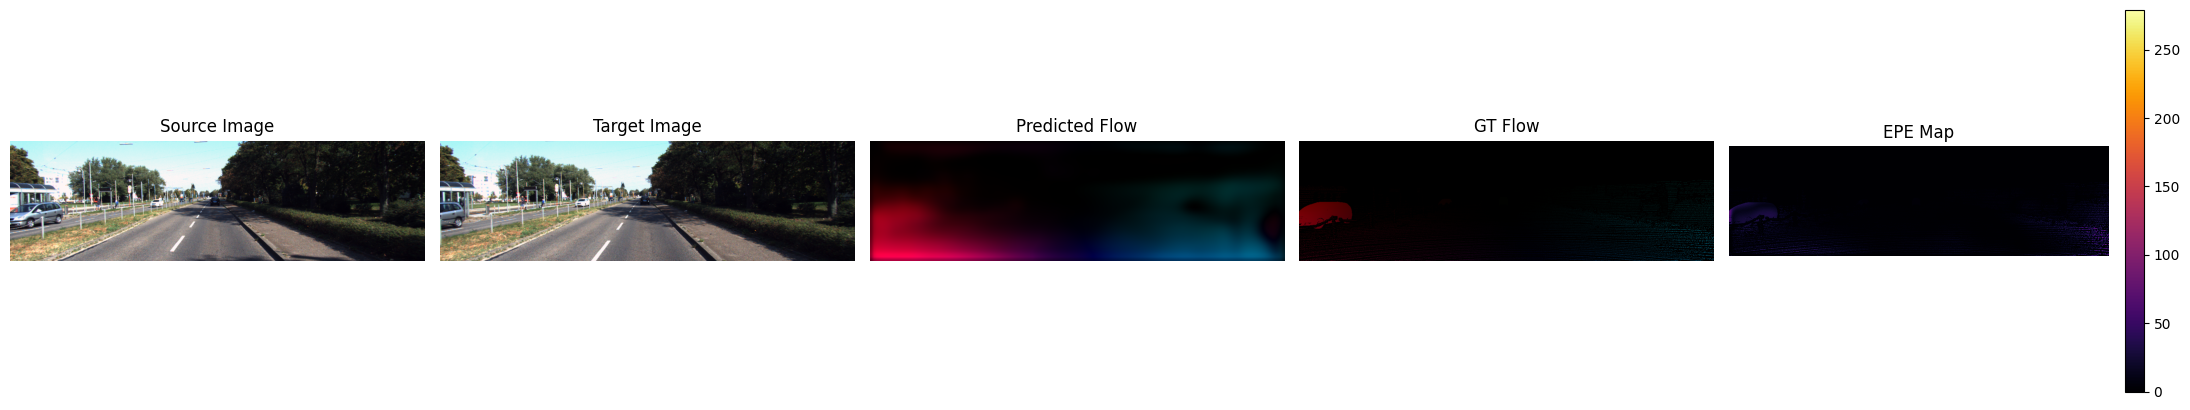

In [67]:
batch = next(iter(train_loader))

imgs = batch["imgs"].to(device)

pair_encoder.eval()
visual_branch.eval()
motion_branch.eval()
fusion.eval()
uno.eval()
decoder.eval()

with torch.no_grad():
    out = forward_pipeline(
        imgs,
        pair_encoder,
        visual_branch,
        motion_branch,
        fusion,
        uno,
        decoder,
    )

pred_flows = out["flows"].cpu()
visualize_batch_result(batch, pred_flows, sample_idx=0)